In [8]:
# =============================================================
# 当当网 Python 类图书销量前50 书名词频分析
# 分析流程：数据清洗 → 词频统计 → 柱状图 → Bigram → TF-IDF → 共现网络
# 依赖：pandas, numpy, matplotlib, scikit-learn, networkx, jieba
# 安装：pip install jieba
# 可选：wordcloud（pip install wordcloud）
# =============================================================

import pandas as pd
import numpy as np
import re
import os
import warnings
from collections import Counter
import jieba
import jieba.analyse
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from itertools import combinations
from sklearn.feature_extraction.text import TfidfVectorizer
import networkx as nx

warnings.filterwarnings("ignore")

# ── 路径配置 ────────────────────────────────────────────────────
CSV_PATH   = r"C:\Users\Administrator\Desktop\python\dangdang\dangdang_python_books_clean.csv"
OUTPUT_DIR = r"C:\Users\Administrator\Desktop\python\dangdang"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ════════════════════════════════════════════════════════════════
# 工具：中文字体检测
# ════════════════════════════════════════════════════════════════
def get_chinese_font():
    candidates = ["SimHei", "Microsoft YaHei", "PingFang SC",
                  "WenQuanYi Micro Hei", "Noto Sans CJK SC"]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    for p in [r"C:\Windows\Fonts\simhei.ttf", r"C:\Windows\Fonts\msyh.ttc",
              "/usr/share/fonts/truetype/wqy/wqy-microhei.ttc"]:
        if os.path.exists(p):
            fm.fontManager.addfont(p)
            return fm.FontProperties(fname=p).get_name()
    return None

FONT_NAME = get_chinese_font()
if FONT_NAME:
    matplotlib.rcParams["font.family"] = FONT_NAME
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 150


In [9]:
# ════════════════════════════════════════════════════════════════
# STEP 0  读取数据
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 0  读取数据")
print("=" * 60)

df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df = df.dropna(subset=["书名"]).reset_index(drop=True)
titles_raw = df["书名"].tolist()
print(f"共读取 {len(titles_raw)} 条书名")

STEP 0  读取数据
共读取 50 条书名


In [10]:
# ════════════════════════════════════════════════════════════════
# STEP 1  数据清洗 & 分词（jieba 精确模式）
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 1  数据清洗 & 分词（jieba）")
print("=" * 60)

DOMAIN_WORDS = [
    "深度学习", "机器学习", "数据分析", "数据科学", "网络爬虫", "办公自动化",
    "量化交易", "量化投资", "自然语言处理", "人工智能", "线性代数", "强化学习",
    "全栈开发", "数据可视化", "区块链", "青少年编程", "小学生编程", "编程思维",
    "从入门到实践", "从入门到精通", "从入门到全栈开发", "量化交易实战",
    "办公自动化实战", "模式识别", "音乐信号处理",
]
for w in DOMAIN_WORDS:
    jieba.add_word(w, freq=1000)

STOPWORDS = {
    "的", "了", "和", "与", "或", "及", "等", "从", "到", "用", "在", "是", "有", "为", "让",
    "向", "你", "我", "他", "这", "那", "之", "但", "都", "把", "被", "所", "以", "上", "下",
    "版", "第", "本", "册", "书", "图书", "全", "新", "原书", "全彩版", "语言", "日本",
    "附赠", "配套", "视频", "源代码", "课件", "速查", "地图", "路线图", "教学", "教学版",
    "微课", "很简单",
    "简单", "完全", "快速", "轻松", "高效", "深入", "实用", "全面", "权威", "经典", "最新",
    "使用", "基于", "实现", "学习", "掌握", "提升", "带你", "借助", "升级",
    "python", "Python",
}

def clean_title(title: str) -> str:
    title = title.split("，")[0].split(",")[0]
    title = re.sub(r"[（(【\[].+?[）)\]】]", " ", title)
    title = re.sub(r"[A-Za-z0-9+:：\-\+\*\.]+", " ", title)
    title = re.sub(r"[^\u4e00-\u9fa5\s]", " ", title)
    return title.strip()

def tokenize(text: str) -> list:
    return [w for w in jieba.cut(text, cut_all=False) if len(w) >= 2]

all_words = []
title_word_lists = []
for title in titles_raw:
    cleaned  = clean_title(title)
    words    = tokenize(cleaned)
    filtered = [w for w in words if w not in STOPWORDS]
    all_words.extend(filtered)
    title_word_lists.append(filtered)

print(f"清洗后总词数（含重复）：{len(all_words)}")
print(f"不重复词种数：{len(set(all_words))}")
print("\n分词示例：")
for t, wl in list(zip(titles_raw, title_word_lists))[:5]:
    print(f"  {t[:35]!r}")
    print(f"    → {wl}")


STEP 1  数据清洗 & 分词（jieba）
清洗后总词数（含重复）：267
不重复词种数：162

分词示例：
  'Python编程从入门到实践 第3版 Python编程入门经典，自学利'
    → ['编程', '从入门到实践', '编程', '入门']
  'Python网络爬虫与数据分析从入门到实践'
    → ['网络爬虫', '数据分析', '从入门到实践']
  'Python完全自学教程'
    → ['自学', '教程']
  '深度学习的数学――使用Python语言'
    → ['深度学习', '数学']
  'Python+Office:轻松实现Python办公自动化'
    → ['办公自动化']


In [11]:
# ════════════════════════════════════════════════════════════════
# STEP 2  词频统计（Counter）
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 2  词频统计 Top 20")
print("=" * 60)

word_counter = Counter(all_words)
top20 = word_counter.most_common(20)

print(f"{'排名':<5} {'词汇':<15} {'出现次数'}")
print("-" * 30)
for rank, (word, count) in enumerate(top20, 1):
    print(f"{rank:<5} {word:<15} {count}")


STEP 2  词频统计 Top 20
排名    词汇              出现次数
------------------------------
1     编程              19
2     入门              17
3     深度学习            8
4     机器学习            8
5     从入门到实践          5
6     教程              5
7     人工智能            4
8     实践              4
9     项目              4
10    网络爬虫            3
11    数据分析            3
12    理论              3
13    量化交易            3
14    从入门到精通          3
15    策略              3
16    指南              3
17    金融              3
18    量化交易实战          3
19    数学              2
20    办公              2


In [12]:
# ════════════════════════════════════════════════════════════════
# STEP 3  Bigram 分析（相邻词对）
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 3  Bigram 分析 Top 15")
print("=" * 60)

bigrams = []
for wl in title_word_lists:
    for i in range(len(wl) - 1):
        bigrams.append((wl[i], wl[i + 1]))

bigram_counter = Counter(bigrams)
top_bigrams = bigram_counter.most_common(15)

print(f"{'排名':<5} {'词对':<25} {'次数'}")
print("-" * 35)
for rank, (pair, cnt) in enumerate(top_bigrams, 1):
    print(f"{rank:<5} {' · '.join(pair):<25} {cnt}")


STEP 3  Bigram 分析 Top 15
排名    词对                        次数
-----------------------------------
1     编程 · 从入门到实践               4
2     编程 · 入门                   3
3     深度学习 · 入门                 3
4     入门 · 书籍                   2
5     算法 · 改进                   2
6     金融 · 量化                   2
7     量化 · 分析                   2
8     加减乘除 · 机器学习               2
9     从入门到实践 · 编程               1
10    网络爬虫 · 数据分析               1
11    数据分析 · 从入门到实践             1
12    自学 · 教程                   1
13    深度学习 · 数学                 1
14    自动化 · 办公                  1
15    办公 · 告别                   1


In [13]:
# ════════════════════════════════════════════════════════════════
# STEP 4  TF-IDF 分析
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 4  TF-IDF 分析 Top 20")
print("=" * 60)

corpus = [" ".join(wl) if wl else "空" for wl in title_word_lists]
vectorizer = TfidfVectorizer(
    token_pattern=r"[\u4e00-\u9fa5]{2,}",
    min_df=1,
    max_df=0.90,
)
tfidf_matrix = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

tfidf_df = pd.DataFrame({
    "词汇": feature_names,
    "平均TF-IDF": mean_tfidf
}).sort_values("平均TF-IDF", ascending=False)

print(tfidf_df.head(20).to_string(index=False))


STEP 4  TF-IDF 分析 Top 20
     词汇  平均TF-IDF
     编程  0.106062
     入门  0.087993
 从入门到实践  0.058268
   深度学习  0.052553
 从入门到精通  0.048252
   机器学习  0.042789
 量化交易实战  0.033714
     教程  0.033368
   网络爬虫  0.032650
     项目  0.031109
   数据分析  0.028298
     实践  0.026775
     实战  0.025831
     指南  0.025792
   人工智能  0.023010
   数据科学  0.022174
     策略  0.020536
   量化交易  0.020177
  办公自动化  0.020000
办公自动化实战  0.020000



STEP 5  生成综合可视化图表


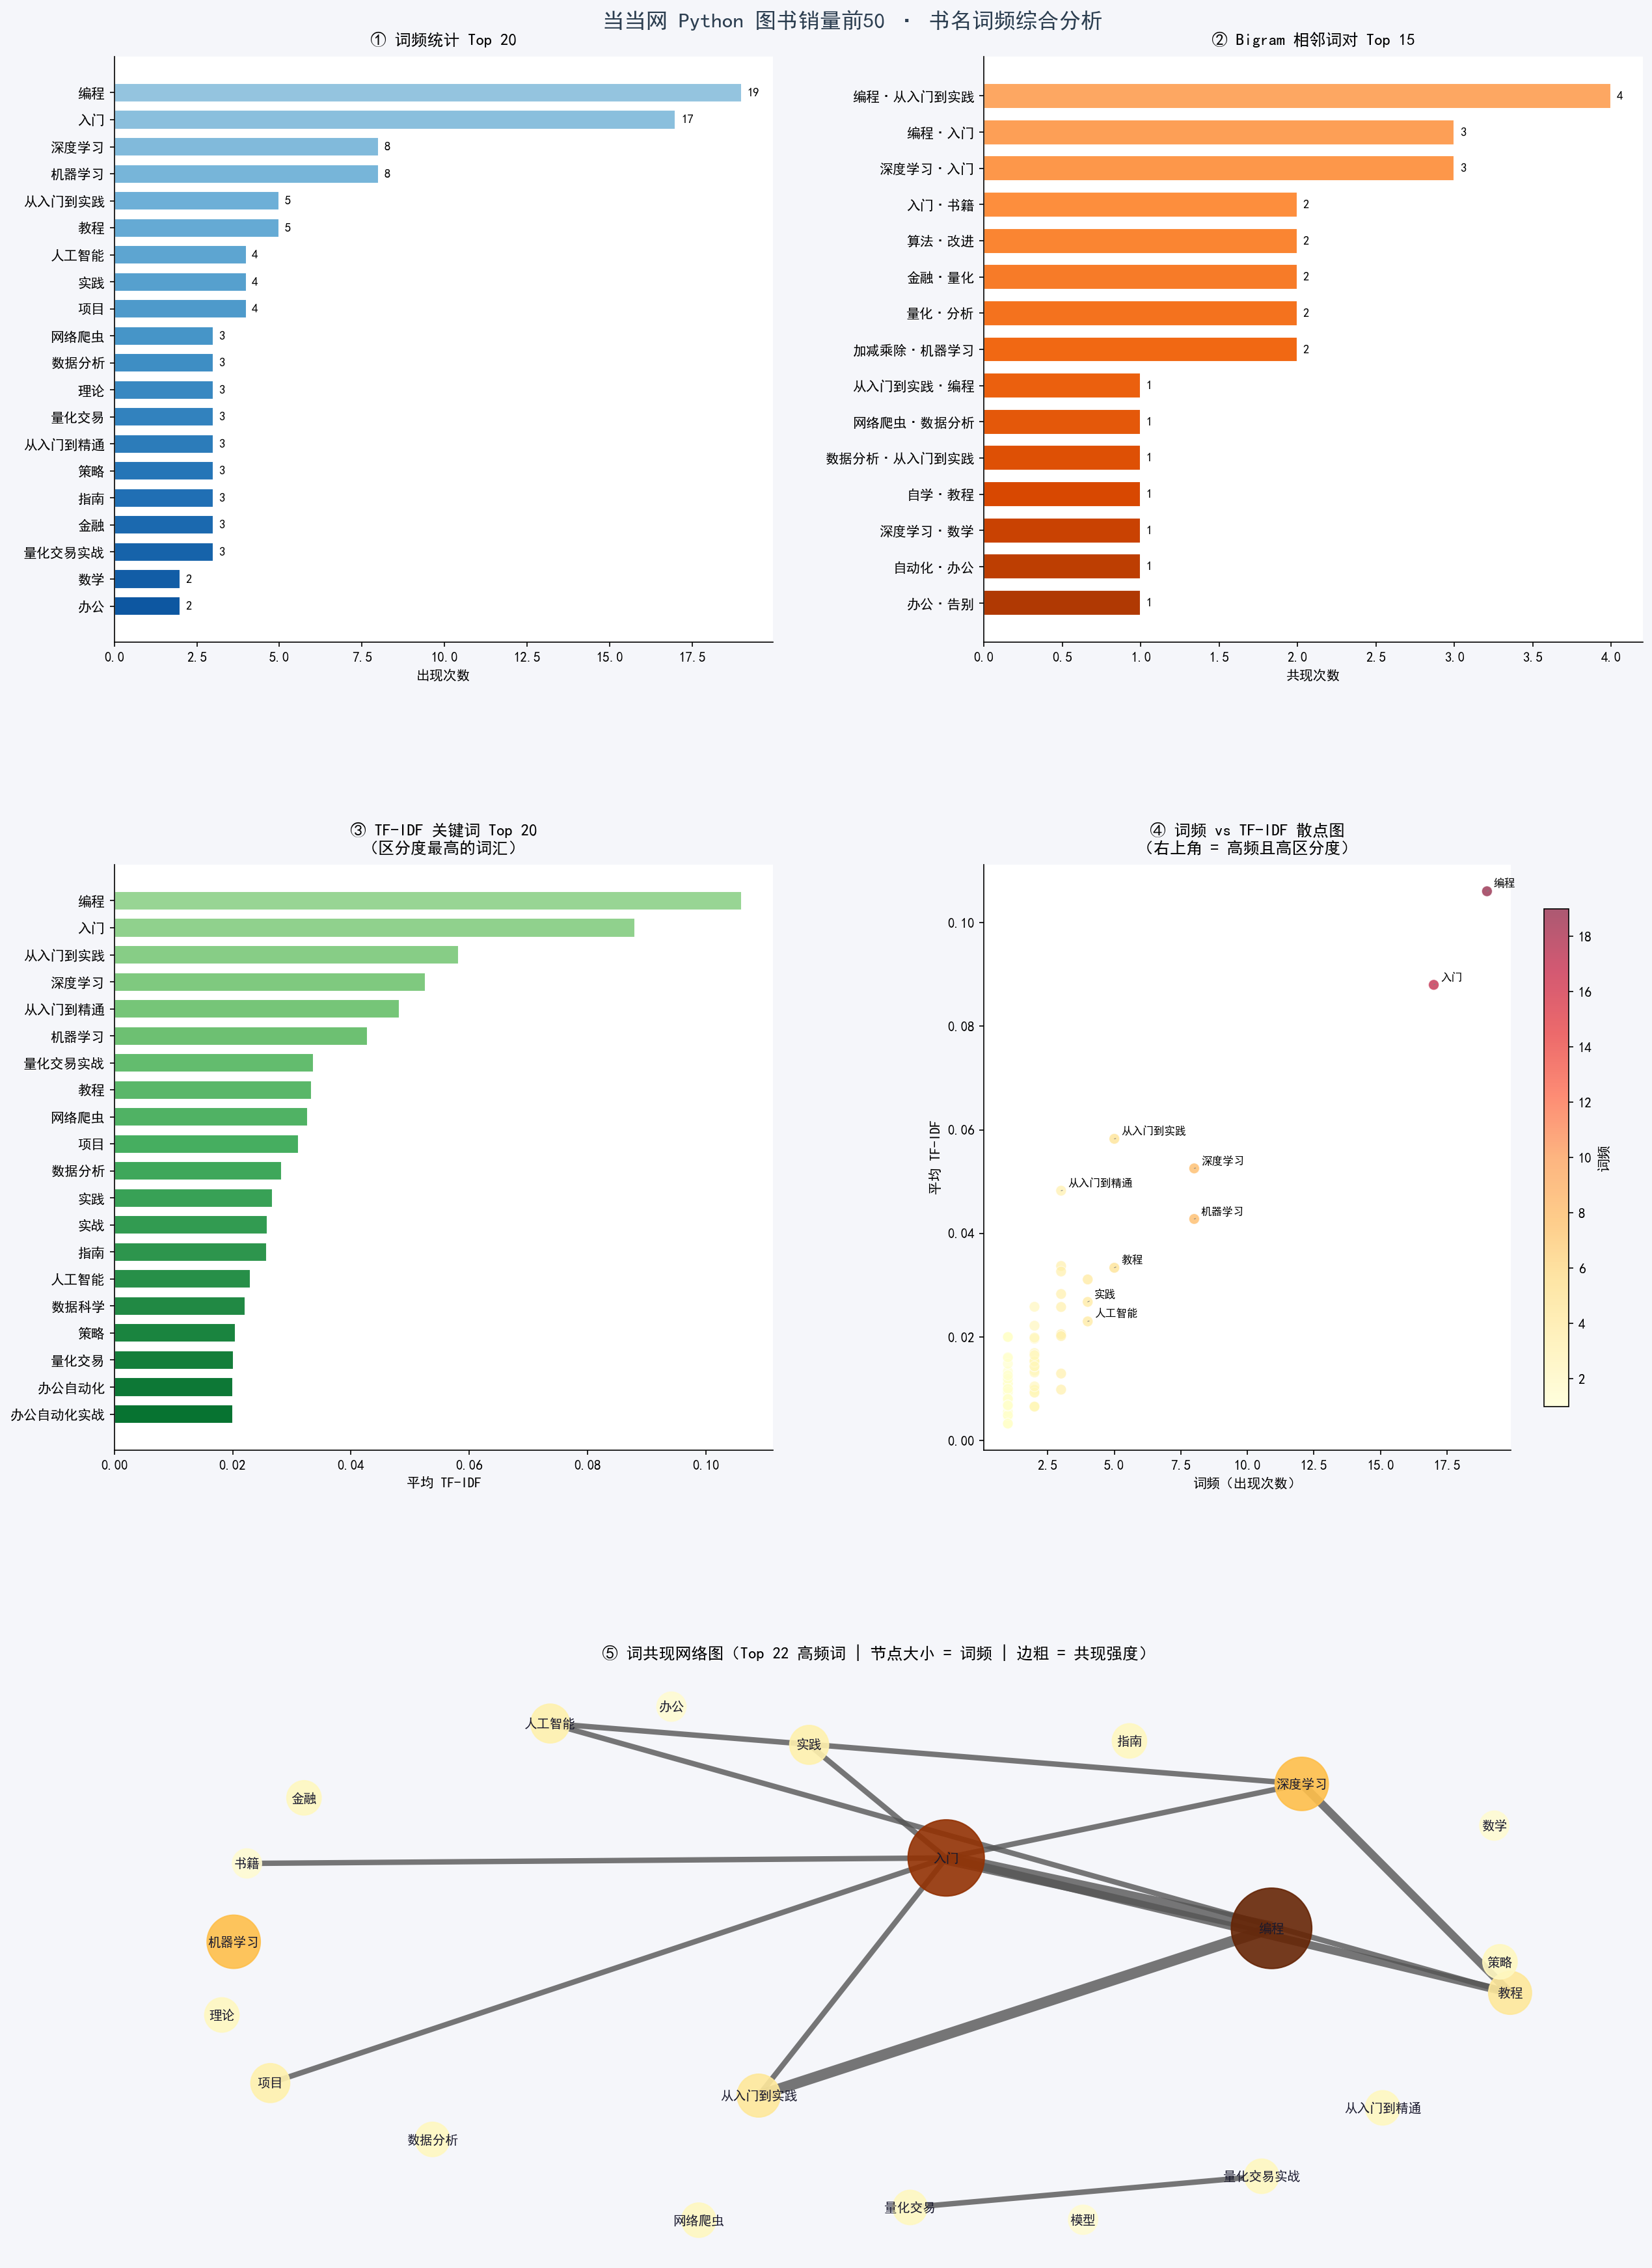

In [14]:
# ════════════════════════════════════════════════════════════════
# STEP 5  综合可视化（5合1图表）
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 5  生成综合可视化图表")
print("=" * 60)

fig = plt.figure(figsize=(18, 24))
fig.patch.set_facecolor("#f5f6fa")
fig.suptitle("当当网 Python 图书销量前50 · 书名词频综合分析",
             fontsize=16, fontweight="bold", y=0.99, color="#2c3e50")

# ── 子图①：词频 Top 20 柱状图 ──────────────────────────────────
ax1 = fig.add_subplot(3, 2, 1)
ax1.set_facecolor("white")
wl_ = [w for w, _ in top20]
cl_ = [c for _, c in top20]
blues = plt.cm.Blues(np.linspace(0.4, 0.85, len(wl_)))
b1 = ax1.barh(wl_[::-1], cl_[::-1], color=blues[::-1], height=0.7, edgecolor="white")
ax1.bar_label(b1, padding=4, fontsize=9)
ax1.set_xlabel("出现次数", fontsize=10)
ax1.set_title("① 词频统计 Top 20", fontsize=12, fontweight="bold", pad=8)
ax1.spines[["top", "right"]].set_visible(False)

# ── 子图②：Bigram 柱状图 ───────────────────────────────────────
ax2 = fig.add_subplot(3, 2, 2)
ax2.set_facecolor("white")
bg_l = [f"{a}·{b}" for (a, b), _ in top_bigrams]
bg_c = [c for _, c in top_bigrams]
oranges = plt.cm.Oranges(np.linspace(0.4, 0.85, len(bg_l)))
b2 = ax2.barh(bg_l[::-1], bg_c[::-1], color=oranges[::-1], height=0.7, edgecolor="white")
ax2.bar_label(b2, padding=4, fontsize=9)
ax2.set_xlabel("共现次数", fontsize=10)
ax2.set_title("② Bigram 相邻词对 Top 15", fontsize=12, fontweight="bold", pad=8)
ax2.spines[["top", "right"]].set_visible(False)

# ── 子图③：TF-IDF Top 20 柱状图 ───────────────────────────────
ax3 = fig.add_subplot(3, 2, 3)
ax3.set_facecolor("white")
top20_tfidf = tfidf_df.head(20)
tw = top20_tfidf["词汇"].tolist()
ts = top20_tfidf["平均TF-IDF"].tolist()
greens = plt.cm.Greens(np.linspace(0.4, 0.85, len(tw)))
ax3.barh(tw[::-1], ts[::-1], color=greens[::-1], height=0.7, edgecolor="white")
ax3.set_xlabel("平均 TF-IDF", fontsize=10)
ax3.set_title("③ TF-IDF 关键词 Top 20\n（区分度最高的词汇）",
              fontsize=12, fontweight="bold", pad=8)
ax3.spines[["top", "right"]].set_visible(False)

# ── 子图④：词频 vs TF-IDF 散点图 ──────────────────────────────
ax4 = fig.add_subplot(3, 2, 4)
ax4.set_facecolor("white")
all_vocab = list(set(all_words))
freq_a  = [word_counter[w] for w in all_vocab]
tdict   = dict(zip(feature_names, mean_tfidf))
tfidf_a = [tdict.get(w, 0) for w in all_vocab]
sc = ax4.scatter(freq_a, tfidf_a, alpha=0.65, c=freq_a, cmap="YlOrRd",
                 s=60, edgecolor="white", linewidth=0.5)
plt.colorbar(sc, ax=ax4, label="词频", shrink=0.85)
highlight = set([w for w, _ in top20[:8]] + tfidf_df["词汇"].head(5).tolist())
for w in highlight:
    if w in all_vocab:
        i = all_vocab.index(w)
        ax4.annotate(w, (freq_a[i], tfidf_a[i]), fontsize=8,
                     xytext=(5, 3), textcoords="offset points",
                     arrowprops=dict(arrowstyle="-", lw=0.5, color="gray"))
ax4.set_xlabel("词频（出现次数）", fontsize=10)
ax4.set_ylabel("平均 TF-IDF", fontsize=10)
ax4.set_title("④ 词频 vs TF-IDF 散点图\n（右上角 = 高频且高区分度）",
              fontsize=12, fontweight="bold", pad=8)
ax4.spines[["top", "right"]].set_visible(False)

# ── 子图⑤：词共现网络图 ────────────────────────────────────────
ax5 = fig.add_subplot(3, 1, 3)
ax5.set_facecolor("white")
topN = {w for w, _ in word_counter.most_common(22)}
co_c = Counter()
for wl in title_word_lists:
    fl = [w for w in wl if w in topN]
    for pair in combinations(set(fl), 2):
        co_c[tuple(sorted(pair))] += 1

G = nx.Graph()
for (w1, w2), wt in co_c.items():
    if wt >= 2:
        G.add_edge(w1, w2, weight=wt)
for w in topN:
    if w not in G:
        G.add_node(w)

nf = [word_counter[n] for n in G.nodes()]
ns = [f * 180 + 100 for f in nf]
ew = [G[u][v]["weight"] * 2 for u, v in G.edges()]
pos = nx.spring_layout(G, seed=42, k=2.5)
nx.draw_networkx_nodes(G, pos, node_size=ns, node_color=nf,
                       cmap=plt.cm.YlOrBr, alpha=0.9, ax=ax5, vmin=1)
nx.draw_networkx_edges(G, pos, width=ew, edge_color="#555555", alpha=0.8, ax=ax5)
nx.draw_networkx_labels(G, pos, font_size=9.5, ax=ax5,
                        font_family=FONT_NAME or "sans-serif", font_color="#1a1a2e")
ax5.set_title(
    "⑤ 词共现网络图（Top 22 高频词 | 节点大小 = 词频 | 边粗 = 共现强度）",
    fontsize=12, fontweight="bold", pad=10)
ax5.axis("off")

plt.subplots_adjust(left=0.08, right=0.95, top=0.97, bottom=0.03,
                    hspace=0.38, wspace=0.32)
plt.show()  # ← 直接展示，不保存文件


STEP 6  词云图（可选）


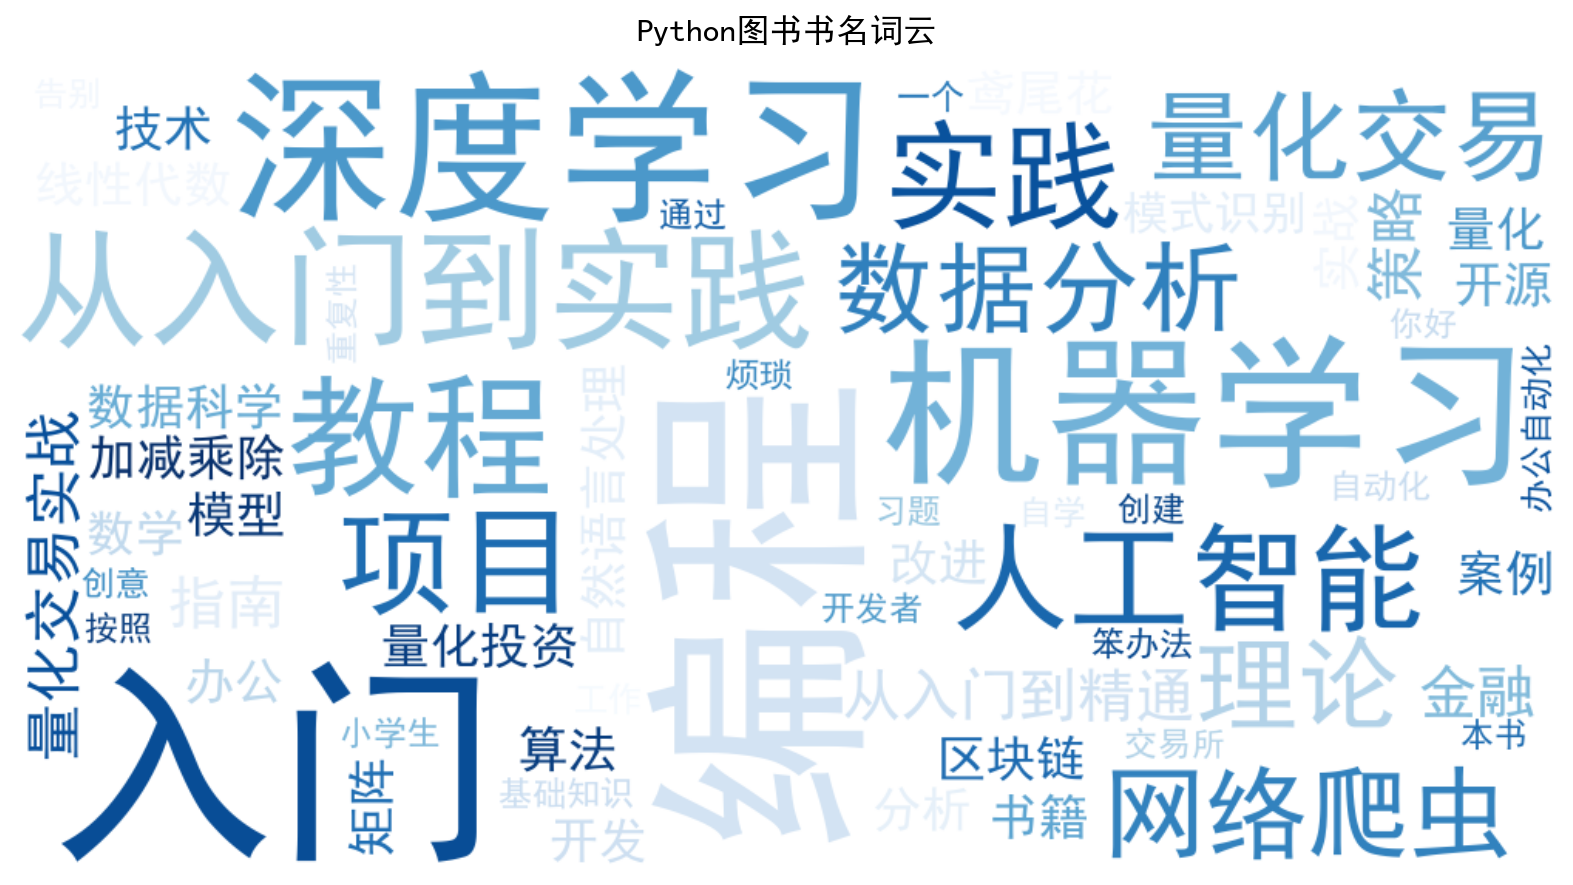

In [15]:
# ════════════════════════════════════════════════════════════════
# STEP 6  词云图（需安装 wordcloud）
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 6  词云图（可选）")
print("=" * 60)

try:
    from wordcloud import WordCloud

    font_path = None
    for p in [r"C:\Windows\Fonts\simhei.ttf", r"C:\Windows\Fonts\msyh.ttc",
              "/usr/share/fonts/truetype/wqy/wqy-microhei.ttc"]:
        if os.path.exists(p):
            font_path = p
            break

    wc = WordCloud(
        font_path=font_path,
        width=1000, height=520,
        background_color="white",
        colormap="Blues",
        max_words=60,
        min_font_size=10,
    ).generate_from_frequencies(dict(word_counter))

    fig2, ax = plt.subplots(figsize=(13, 6))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Python图书书名词云", fontsize=16, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.show()  # ← 直接展示，不保存文件
except ImportError:
    print("[跳过] wordcloud 未安装：pip install wordcloud")

In [16]:
# ════════════════════════════════════════════════════════════════
# STEP 7  摘要输出
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 7  分析摘要")
print("=" * 60)
print(f"▶ 词频 Top 5：{[w for w,_ in top20[:5]]}")
print(f"▶ TF-IDF Top 5（有区分度）：{tfidf_df['词汇'].head(5).tolist()}")
print(f"▶ 最常见 Bigram：{[f'{a}·{b}' for (a,b),_ in top_bigrams[:3]]}")
print(f"▶ 共现网络：{G.number_of_nodes()} 个节点，{G.number_of_edges()} 条边")
print("\n分析完成 ✓")


STEP 7  分析摘要
▶ 词频 Top 5：['编程', '入门', '深度学习', '机器学习', '从入门到实践']
▶ TF-IDF Top 5（有区分度）：['编程', '入门', '从入门到实践', '深度学习', '从入门到精通']
▶ 最常见 Bigram：['编程·从入门到实践', '编程·入门', '深度学习·入门']
▶ 共现网络：22 个节点，12 条边

分析完成 ✓
